In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(460, 14)
(115, 14)


In [3]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2

In [4]:
results = {}

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0.28,-0.59, 1.09,..., 0.92, 0.04, 2.29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['best_rank','worst_rank','avg_rank',...,'playlist_entries','days_to_peak', 'stability_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.279
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [6]:
mae, rmse, r2 = evaluate_model(
    lr,
    X_test,
    y_test
)

results["Linear Regression"] = [mae, rmse, r2]

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 12.284162630116294
RMSE: 37.59921012569163
R² : 0.895368531757012


In [7]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

mae, rmse, r2 = evaluate_model(
    tree,
    X_test,
    y_test
)

results["Decision Tree"] = [mae, rmse, r2]

In [8]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

mae, rmse, r2 = evaluate_model(
    rf,
    X_test,
    y_test
)

results["Random Forest"] = [mae, rmse, r2]

In [9]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

mae, rmse, r2 = evaluate_model(
    gb,
    X_test,
    y_test
)

results["Gradient Boosting"] = [mae, rmse, r2]

In [10]:
comparison = pd.DataFrame(
    results,
    index=["MAE", "RMSE", "R²"]
).T

comparison

,MAE,RMSE,R²
Linear Regression,12.284163,37.599210,0.895369
Decision Tree,17.843478,53.908780,0.784908
Random Forest,11.753130,39.207339,0.886227
Gradient Boosting,10.116160,33.519053,0.916845


In [11]:
comparison.sort_values(
    "R²",
    ascending=False
)

,MAE,RMSE,R²
Gradient Boosting,10.116160,33.519053,0.916845
Linear Regression,12.284163,37.599210,0.895369
Random Forest,11.753130,39.207339,0.886227
Decision Tree,17.843478,53.908780,0.784908


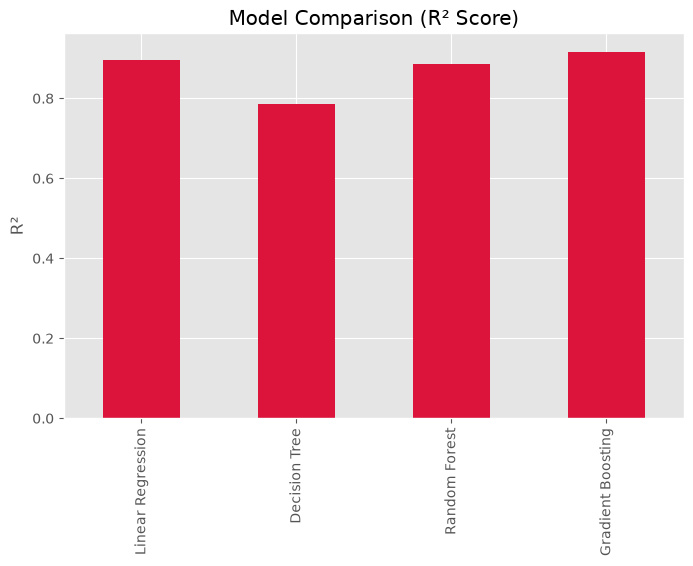

In [13]:
plt.figure(figsize=(8,5))

comparison["R²"].plot(
    kind="bar",
    color="crimson"
)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R²")
plt.show()

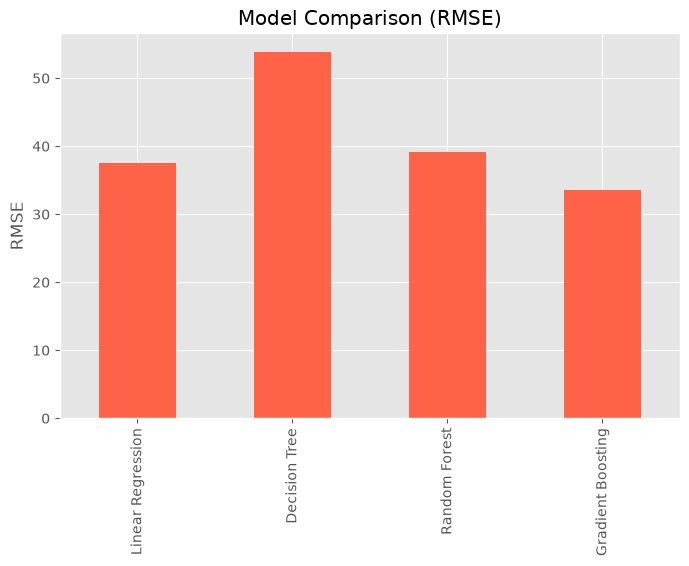

In [14]:
plt.figure(figsize=(8,5))

comparison["RMSE"].plot(
    kind="bar",
    color="tomato"
)

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

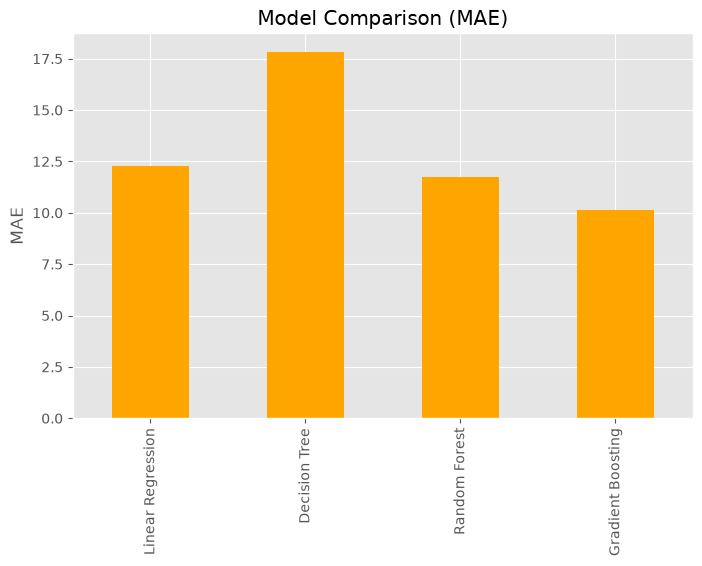

In [15]:
plt.figure(figsize=(8,5))

comparison["MAE"].plot(
    kind="bar",
    color="orange"
)

plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")
plt.show()

In [16]:
comparison.to_csv(
    "../data/model_comparison.csv",
    index=True
)

# Baseline Model Summary

Four regression models were trained and evaluated on the prepared dataset.

Evaluation Metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² and the lowest MAE/RMSE will be selected for further tuning and interpretation in the next notebook.